In [3]:
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
df = pd.read_csv('../data/data.csv', encoding = 'latin-1')

In [4]:
# Drop missing CustomerID
df = df.dropna(subset=['CustomerID'])
# Remove cancelled orders
df = df[~df['InvoiceNo'].str.startswith('C')]
# Remove negative quantity
df = df[df['Quantity'] > 0]
# Create Revenue column
df['Revenue'] = df['Quantity'] * df['UnitPrice']
# Convert InvoiceDate to datetime
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

print(df.columns.tolist())
print(df.shape)

['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country', 'Revenue']
(397924, 9)



- Top revenue-generating countries and their contribution to overall sales.
- Helps prioritize international markets and allocate inventory where demand is strongest.

In [5]:
# Q1 - Revenue by Country (top 10)
country_revenue = df.groupby('Country')['Revenue'].sum().sort_values(ascending = False).head(10)
print(country_revenue)

Country
United Kingdom    7308391.554
Netherlands        285446.340
EIRE               265545.900
Germany            228867.140
France             209024.050
Australia          138521.310
Spain               61577.110
Switzerland         56443.950
Belgium             41196.340
Sweden              38378.330
Name: Revenue, dtype: float64



- Monthly revenue totals to reveal seasonality and growth patterns.

- Supports planning for promotions, and inventory to match demand cycles.

In [6]:
# Q2 - Monthly Revenue Trend
df['Month'] = df['InvoiceDate'].dt.to_period('M')
monthly_revenue = df.groupby('Month')['Revenue'].sum()
print(monthly_revenue)

Month
2010-12     572713.890
2011-01     569445.040
2011-02     447137.350
2011-03     595500.760
2011-04     469200.361
2011-05     678594.560
2011-06     661213.690
2011-07     600091.011
2011-08     645343.900
2011-09     952838.382
2011-10    1039318.790
2011-11    1161817.380
2011-12     518192.790
Freq: M, Name: Revenue, dtype: float64



- The top products by revenue to understand which items drive the most sales.
- Highlights product strengths and informs assortment and merchandising decisions.

In [7]:
# Q3 - Top 10 Products by Revenue
product_revenue = df.groupby('Description')['Revenue'].sum().sort_values(ascending=False).head(10)
print(product_revenue)

Description
PAPER CRAFT , LITTLE BIRDIE           168469.60
REGENCY CAKESTAND 3 TIER              142592.95
WHITE HANGING HEART T-LIGHT HOLDER    100448.15
JUMBO BAG RED RETROSPOT                85220.78
MEDIUM CERAMIC TOP STORAGE JAR         81416.73
POSTAGE                                77803.96
PARTY BUNTING                          68844.33
ASSORTED COLOUR BIRD ORNAMENT          56580.34
Manual                                 53779.93
RABBIT NIGHT LIGHT                     51346.20
Name: Revenue, dtype: float64



- The customers generating the highest revenue.
- Identifies who to retain and which customer relationships are most valuable.

In [8]:
# Q4 - Top 10 Customers by Revenue
customer_revenue = df.groupby('CustomerID')['Revenue'].sum().sort_values(ascending=False).head(10)
print(customer_revenue)

CustomerID
14646.0    280206.02
18102.0    259657.30
17450.0    194550.79
16446.0    168472.50
14911.0    143825.06
12415.0    124914.53
14156.0    117379.63
17511.0     91062.38
16029.0     81024.84
12346.0     77183.60
Name: Revenue, dtype: float64



- The month-over-month revenue growth rate.
- Measures momentum and reveals whether sales are accelerating or slowing.

In [9]:
# Q5 - Month over Month Growth Rate
monthly_growth_rate = df.groupby('Month')['Revenue'].sum().pct_change() * 100
print(monthly_growth_rate)

Month
2010-12          NaN
2011-01    -0.570765
2011-02   -21.478401
2011-03    33.180724
2011-04   -21.209108
2011-05    44.627885
2011-06    -2.561304
2011-07    -9.244013
2011-08     7.541004
2011-09    47.648158
2011-10     9.076084
2011-11    11.786431
2011-12   -55.398086
Freq: M, Name: Revenue, dtype: float64


C:\Users\HP\AppData\Local\Temp\ipykernel_5056\3899064030.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=country_revenue.values, y=country_revenue.index, palette='Blues_r')


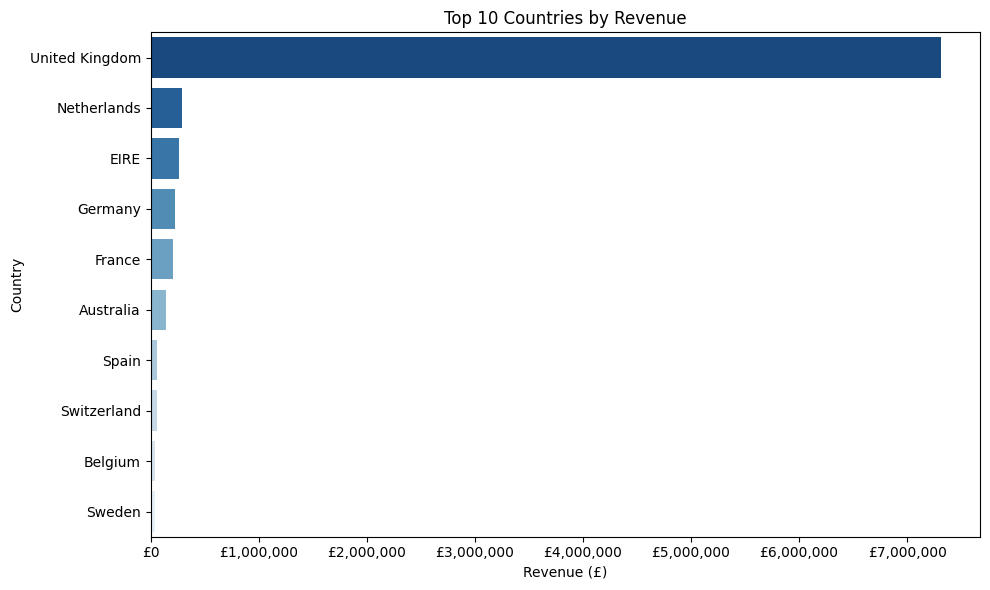

In [10]:
plt.figure(figsize=(10,6))
sns.barplot(x=country_revenue.values, y=country_revenue.index, palette='Blues_r')
plt.title('Top 10 Countries by Revenue')
plt.xlabel('Revenue (£)')
plt.ylabel('Country')
plt.gca().xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f'£{x:,.0f}')
)
plt.tight_layout()
plt.savefig('../visuals/revenue_by_country.png')
plt.show()

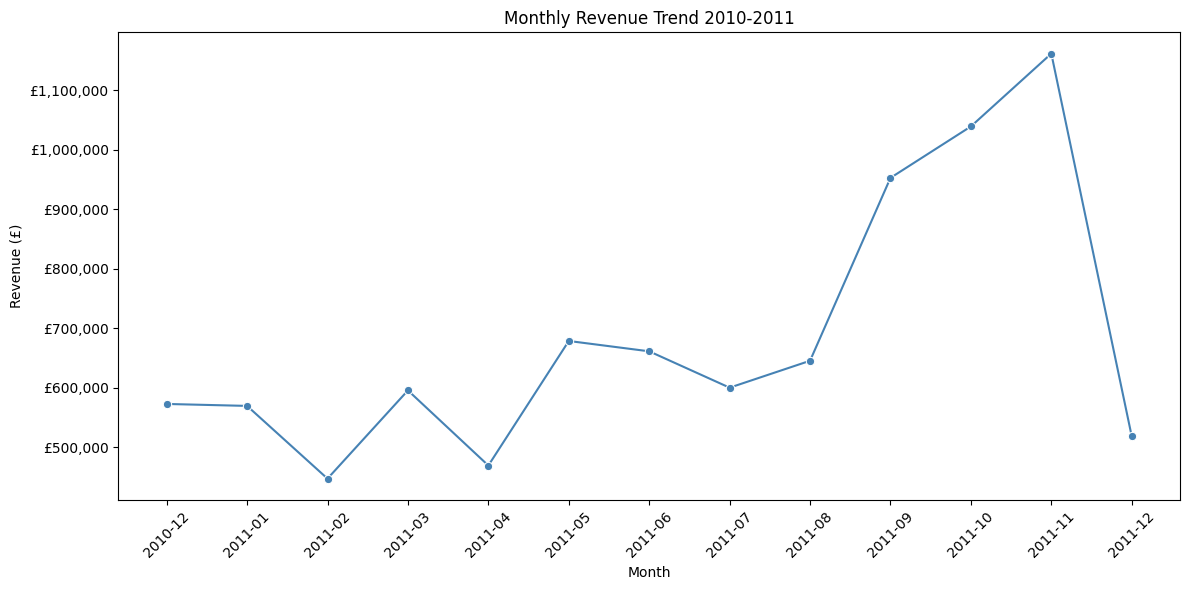

In [11]:
# Chart 2 — Monthly Revenue Trend
plt.figure(figsize=(12,6))
monthly_months = monthly_revenue.index.astype(str)
sns.lineplot(x=monthly_months, y=monthly_revenue.values, color='steelblue', marker='o')
plt.title('Monthly Revenue Trend 2010-2011')
plt.xlabel('Month')
plt.ylabel('Revenue (£)')
plt.xticks(rotation=45)
plt.gca().yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f'£{x:,.0f}')
)
plt.tight_layout()
plt.savefig('../visuals/monthly_revenue_trend.png')
plt.show()

C:\Users\HP\AppData\Local\Temp\ipykernel_5056\721640524.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=product_revenue.values, y=product_revenue.index, palette='Greens_r')


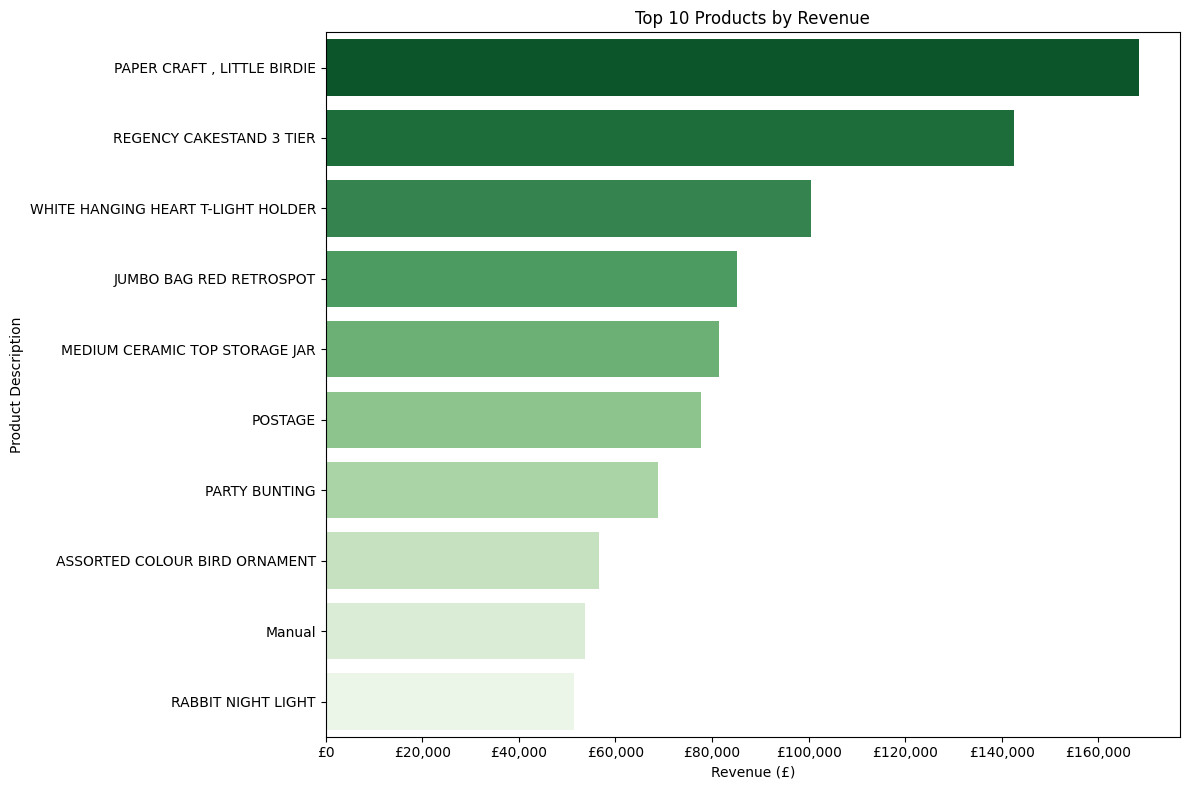

In [12]:
# Chart 3 — Top 10 Products by Revenue
plt.figure(figsize=(12,8))
sns.barplot(x=product_revenue.values, y=product_revenue.index, palette='Greens_r')
plt.title('Top 10 Products by Revenue')
plt.xlabel('Revenue (£)')
plt.ylabel('Product Description')
plt.gca().xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f'£{x:,.0f}')
)
plt.tight_layout()
plt.savefig('../visuals/top_products_by_revenue.png')
plt.show()

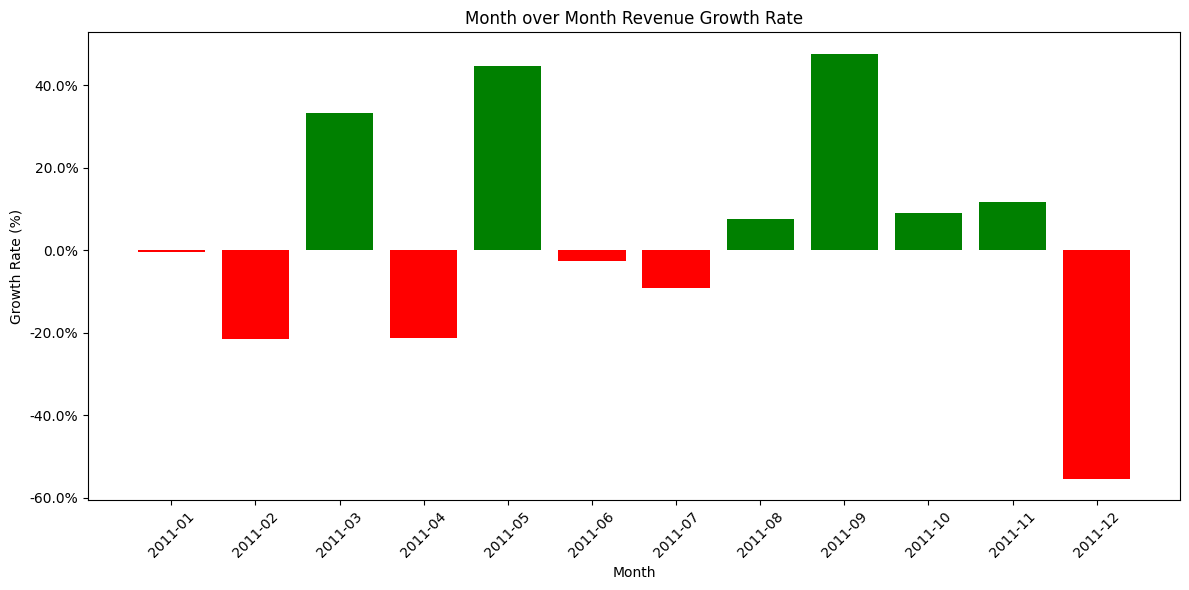

In [13]:
# Chart 4 — Month over Month Growth Rate
plt.figure(figsize=(12,6))
growth_colors = ['green' if v >= 0 else 'red' for v in monthly_growth_rate.values]
plt.bar(monthly_months, monthly_growth_rate.values, color=growth_colors)
plt.title('Month over Month Revenue Growth Rate')
plt.xlabel('Month')
plt.ylabel('Growth Rate (%)')
plt.xticks(rotation=45)
plt.gca().yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f'{x:.1f}%')
)
plt.tight_layout()
plt.savefig('../visuals/month_over_month_growth_rate.png')
plt.show()

In [14]:
import datetime as dt

# Set reference date (day after last invoice)
reference_date = df['InvoiceDate'].max() + dt.timedelta(days=1)

# Build RFM table
rfm = df.groupby('CustomerID').agg(
    Recency=('InvoiceDate', lambda x: (reference_date - x.max()).days),
    Frequency=('InvoiceNo', 'nunique'),
    Monetary=('Revenue', 'sum')
).reset_index()

print(rfm.head(10))
print(rfm.describe())

   CustomerID  Recency  Frequency  Monetary
0     12346.0      326          1  77183.60
1     12347.0        2          7   4310.00
2     12348.0       75          4   1797.24
3     12349.0       19          1   1757.55
4     12350.0      310          1    334.40
5     12352.0       36          8   2506.04
6     12353.0      204          1     89.00
7     12354.0      232          1   1079.40
8     12355.0      214          1    459.40
9     12356.0       23          3   2811.43
         CustomerID      Recency    Frequency       Monetary
count   4339.000000  4339.000000  4339.000000    4339.000000
mean   15299.936852    92.518322     4.271952    2053.793018
std     1721.889758   100.009747     7.705493    8988.248381
min    12346.000000     1.000000     1.000000       0.000000
25%    13812.500000    18.000000     1.000000     307.245000
50%    15299.000000    51.000000     2.000000     674.450000
75%    16778.500000   142.000000     5.000000    1661.640000
max    18287.000000   374.00

In [15]:
# Score customers 1-3 based on RFM values
# For Recency: lower is better (bought recently)
# For Frequency and Monetary: higher is better

rfm['R_Score'] = pd.qcut(rfm['Recency'], q=3, labels=[3,2,1])
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), q=3, labels=[1,2,3])
rfm['M_Score'] = pd.qcut(rfm['Monetary'].rank(method='first'), q=3, labels=[1,2,3])

# Combine scores
rfm['RFM_Score'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)

# Segment customers
def segment_customer(score):
    if score in ['333', '332', '323']:
        return 'Champions'
    elif score in ['311', '312', '313', '321']:
        return 'At Risk'
    elif score in ['111', '112', '121', '122']:
        return 'Lost'
    else:
        return 'Potential'

rfm['Segment'] = rfm['RFM_Score'].apply(segment_customer)

print(rfm['Segment'].value_counts())

Segment
Potential    1908
Lost         1208
Champions     948
At Risk       275
Name: count, dtype: int64


C:\Users\HP\AppData\Local\Temp\ipykernel_5056\2953643058.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=segment_counts.index, y=segment_counts.values, palette=colors)


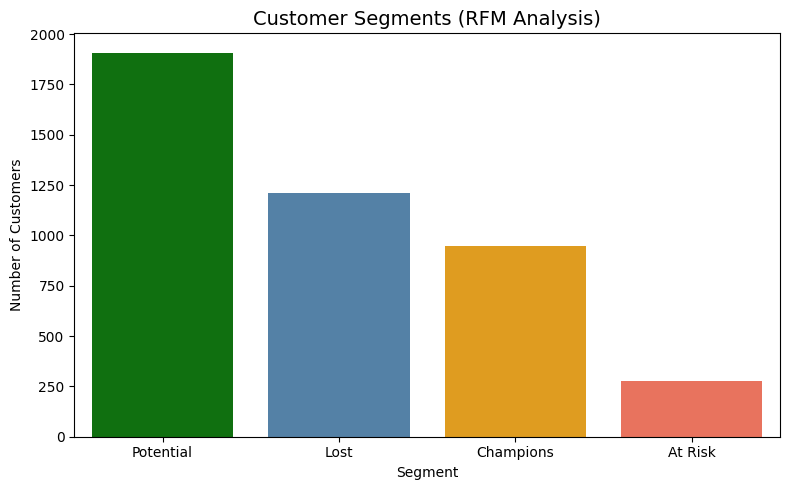

In [16]:
segment_counts = rfm['Segment'].value_counts()

plt.figure(figsize=(8,5))
colors = ['green', 'steelblue', 'orange', 'tomato']
sns.barplot(x=segment_counts.index, y=segment_counts.values, palette=colors)
plt.title('Customer Segments (RFM Analysis)', fontsize=14)
plt.xlabel('Segment')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.savefig('../visuals/customer_segments.png')
plt.show()

- Action 1: Reach out to segment 333 customers with a loyalty offer so Champions keep buying.
- Action 2: Give segment 311 customers a special deal to bring at-risk buyers back soon.
- Action 3: Reduce spend on segment 111 customers and focus more on segments with higher value.

In [17]:
# Define churn: customers who haven't bought in last 90 days
reference_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

customer_last_purchase = df.groupby('CustomerID')['InvoiceDate'].max()

churned = customer_last_purchase[
    (reference_date - customer_last_purchase).dt.days > 90
]

print(f"Total customers: {df['CustomerID'].nunique()}")
print(f"Churned customers (90+ days inactive): {len(churned)}")
print(f"Churn rate: {round(len(churned)/df['CustomerID'].nunique()*100, 2)}%")

Total customers: 4339
Churned customers (90+ days inactive): 1449
Churn rate: 33.39%


1,449 out of 4,339 customers (33.39%) have not purchased in over 90 days. This represents significant lost revenue potential. Cross-referencing with RFM segments shows these are primarily Lost and At-Risk customers who need immediate re-engagement campaigns.


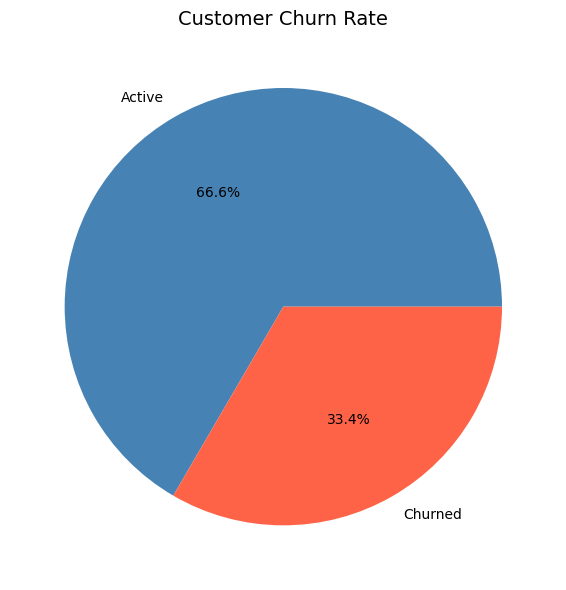

In [18]:
labels = ['Active', 'Churned']
sizes = [4339 - 1449, 1449]

plt.figure(figsize=(6,6))
plt.pie(sizes, labels=labels, autopct='%1.1f%%',
        colors=['steelblue', 'tomato'])
plt.title('Customer Churn Rate', fontsize=14)
plt.tight_layout()
plt.savefig('../visuals/churn_rate.png')
plt.show()

In [19]:
# Export 1 - Monthly Revenue
monthly_revenue.reset_index().to_csv('../data/exports/monthly_revenue.csv', index=False)

# Export 2 - Country Revenue  
country_revenue.reset_index().to_csv('../data/exports/country_revenue.csv', index=False)

# Export 3 - Customer Segments
rfm[['CustomerID','Recency','Frequency','Monetary','Segment']].to_csv('../data/exports/customer_segments.csv', index=False)

# Export 4 - Top Products
product_revenue.reset_index().to_csv('../data/exports/top_products.csv', index=False)